# Zone Classification MLP
CSI 데이터 기반 Zone(4구역) 분류 MLP 학습 노트북

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

print(f"PyTorch: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch: 2.9.1
MPS available: True


## 1. 설정

In [2]:
# --- 설정값 ---
DATA_DIR = os.path.join("..", "data_interpolated_linear_800")
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.0005
NUM_CLASSES = 4

# --- 디바이스 설정 (M1/M2 Mac MPS 지원) ---
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"Data dir: {os.path.abspath(DATA_DIR)}")
print(f"Files found: {len(glob.glob(os.path.join(DATA_DIR, '*_rx1_800.csv')))} experiments")

Using device: mps
Data dir: /Users/seolwootae/ESP-CSI/ESP32_YOLO_Motion_Location_Detect/data_interpolated_linear_800
Files found: 256 experiments


## 2. Zone 라벨 변환 & Dataset 클래스

In [3]:
def get_zone_label(position_idx):
    """ 위치 번호(1~16)를 Zone(0~3)으로 매핑 """
    if position_idx in [1, 2, 5, 6]: return 0      # Zone 1
    elif position_idx in [3, 4, 7, 8]: return 1    # Zone 2
    elif position_idx in [9, 10, 13, 14]: return 2 # Zone 3
    elif position_idx in [11, 12, 15, 16]: return 3 # Zone 4
    else: raise ValueError(f"Invalid position: {position_idx}")

In [4]:
# CSIDataset 클래스는 더 이상 사용하지 않음
# 데이터 로드 셀에서 직접 numpy로 로드 → StandardScaler → TensorDataset 방식으로 변경
# (기존 코드는 정규화 적용이 어려워 아래 데이터 로드 셀로 대체)

## 3. 데이터 로드 & Train/Val 분할

In [5]:
# --- Subject-based 분할 설정 ---
# swt 데이터 제외, 나머지 3명 중 2명 train / 1명 val
EXCLUDE_SUBJECTS = ['swt']
TRAIN_SUBJECTS = ['kjh', 'kmh']
VAL_SUBJECT = 'jhj'

print(f"제외: {EXCLUDE_SUBJECTS}")
print(f"Train subjects: {TRAIN_SUBJECTS}")
print(f"Val subject:    {VAL_SUBJECT}")

# --- 전체 데이터를 numpy로 로드 ---
rx1_files = sorted(glob.glob(os.path.join(DATA_DIR, "*_rx1_800.csv")))
prefixes = [os.path.basename(f).replace('_rx1_800.csv', '') for f in rx1_files]

train_X_list, train_y_list = [], []
val_X_list, val_y_list = [], []
skip_cnt = 0

for prefix in prefixes:
    parts = prefix.split('_')
    subject = parts[0]
    position_idx = int(parts[2])
    label = get_zone_label(position_idx)
    
    # 제외 대상 건너뛰기
    if subject in EXCLUDE_SUBJECTS:
        skip_cnt += 1
        continue
    
    rx_data_list = []
    for i in range(1, 5):
        rx_path = os.path.join(DATA_DIR, f"{prefix}_rx{i}_800.csv")
        df = pd.read_csv(rx_path)
        data = df.iloc[:, -166:].values
        
        if data.shape[0] > 800:
            data = data[:800, :]
        elif data.shape[0] < 800:
            padding = np.zeros((800 - data.shape[0], 166))
            data = np.vstack([data, padding])
        
        rx_data_list.append(data)
    
    merged = np.concatenate(rx_data_list, axis=1)  # (800, 664)
    
    if subject in TRAIN_SUBJECTS:
        train_X_list.append(merged)
        train_y_list.append(label)
    elif subject == VAL_SUBJECT:
        val_X_list.append(merged)
        val_y_list.append(label)

X_train_raw = np.array(train_X_list, dtype=np.float32)
y_train = np.array(train_y_list, dtype=np.int64)
X_val_raw = np.array(val_X_list, dtype=np.float32)
y_val = np.array(val_y_list, dtype=np.int64)

train_size = len(y_train)
val_size = len(y_val)
total_size = train_size + val_size

print(f"\n제외된 실험 수: {skip_cnt} ({EXCLUDE_SUBJECTS})")
print(f"사용 데이터: {total_size} | Train: {train_size} ({TRAIN_SUBJECTS}) | Val: {val_size} ({VAL_SUBJECT})")
print(f"정규화 전 — min: {X_train_raw.min():.2f}, max: {X_train_raw.max():.2f}, mean: {X_train_raw.mean():.2f}")

# --- StandardScaler: train에서 fit, val은 transform만 ---
scaler = StandardScaler()
N_tr, T, D = X_train_raw.shape
X_train_scaled = scaler.fit_transform(X_train_raw.reshape(-1, D)).reshape(N_tr, T, D)

N_va = X_val_raw.shape[0]
X_val_scaled = scaler.transform(X_val_raw.reshape(-1, D)).reshape(N_va, T, D)

print(f"정규화 후 — train mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")

# --- TensorDataset & DataLoader ---
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val_scaled, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Zone 분포 (train): {np.bincount(y_train)}")
print(f"Zone 분포 (val):   {np.bincount(y_val)}")

제외: ['swt']
Train subjects: ['kjh', 'kmh']
Val subject:    jhj

제외된 실험 수: 64 (['swt'])
사용 데이터: 192 | Train: 128 (['kjh', 'kmh']) | Val: 64 (jhj)
정규화 전 — min: 0.00, max: 181.02, mean: 30.69
정규화 후 — train mean: -0.0000, std: 1.0000
Zone 분포 (train): [32 32 32 32]
Zone 분포 (val):   [16 16 16 16]


## 4. MLP 모델 정의

In [6]:
class ZoneMLP(nn.Module):
    def __init__(self, input_dim=664, num_stats=4, num_classes=4):
        """
        시간축에서 mean/std/max/min 4개 통계량을 추출한 뒤 MLP 분류
        input_dim * num_stats = 664 * 4 = 2656
        """
        super(ZoneMLP, self).__init__()
        feat_dim = input_dim * num_stats  # 2656
        
        self.fc1 = nn.Linear(feat_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x: (Batch, 800, 664)
        x_mean = x.mean(dim=1)          # (B, 664)
        x_std  = x.std(dim=1)           # (B, 664)
        x_max  = x.max(dim=1).values    # (B, 664)
        x_min  = x.min(dim=1).values    # (B, 664)
        x = torch.cat([x_mean, x_std, x_max, x_min], dim=1)  # (B, 2656)
        
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.fc3(x)  # (B, num_classes)
        return x

model = ZoneMLP(num_classes=NUM_CLASSES).to(device)
print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")

ZoneMLP(
  (fc1): Linear(in_features=2656, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total params: 348,996


## 5. 학습

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
best_epoch = 0
early_stop_patience = 10
early_stop_counter = 0
save_path = "best_zone_mlp.pt"

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct = 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data).item()
    
    epoch_train_loss = train_loss / train_size
    epoch_train_acc = train_correct / train_size
    
    # --- Validation ---
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
    
    epoch_val_loss = val_loss / val_size
    epoch_val_acc = val_correct / val_size
    
    # LR 스케줄러 업데이트
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # 기록
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    # Best model 저장
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), save_path)
        early_stop_counter = 0
        marker = " ★ saved"
    else:
        early_stop_counter += 1
        marker = ""
    
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")
    
    # Early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"\n⏹ Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs)")
        break

# Best 모델 복원
model.load_state_dict(torch.load(save_path, weights_only=True))
print(f"\n✅ Training Complete! Best Val Loss: {best_val_loss:.4f} at Epoch {best_epoch}")

Epoch [ 1/50] Train Loss: 1.3042 Acc: 0.4062 | Val Loss: 1.1155 Acc: 0.5781 | LR: 0.000500 ★ saved
Epoch [ 2/50] Train Loss: 0.9727 Acc: 0.6719 | Val Loss: 0.9017 Acc: 0.6719 | LR: 0.000500 ★ saved
Epoch [ 3/50] Train Loss: 0.8243 Acc: 0.8203 | Val Loss: 0.8028 Acc: 0.7969 | LR: 0.000500 ★ saved
Epoch [ 4/50] Train Loss: 0.7681 Acc: 0.8281 | Val Loss: 0.7725 Acc: 0.7969 | LR: 0.000500 ★ saved
Epoch [ 5/50] Train Loss: 0.6970 Acc: 0.8828 | Val Loss: 0.7647 Acc: 0.7812 | LR: 0.000500 ★ saved
Epoch [ 6/50] Train Loss: 0.6299 Acc: 0.8906 | Val Loss: 0.7371 Acc: 0.7969 | LR: 0.000500 ★ saved
Epoch [ 7/50] Train Loss: 0.5788 Acc: 0.8984 | Val Loss: 0.7308 Acc: 0.8281 | LR: 0.000500 ★ saved
Epoch [ 8/50] Train Loss: 0.5441 Acc: 0.9141 | Val Loss: 0.7149 Acc: 0.8125 | LR: 0.000500 ★ saved
Epoch [ 9/50] Train Loss: 0.5064 Acc: 0.9297 | Val Loss: 0.6837 Acc: 0.8594 | LR: 0.000500 ★ saved
Epoch [10/50] Train Loss: 0.4520 Acc: 0.9531 | Val Loss: 0.6488 Acc: 0.8750 | LR: 0.000500 ★ saved
Epoch [11/

## 6. 학습 결과 시각화

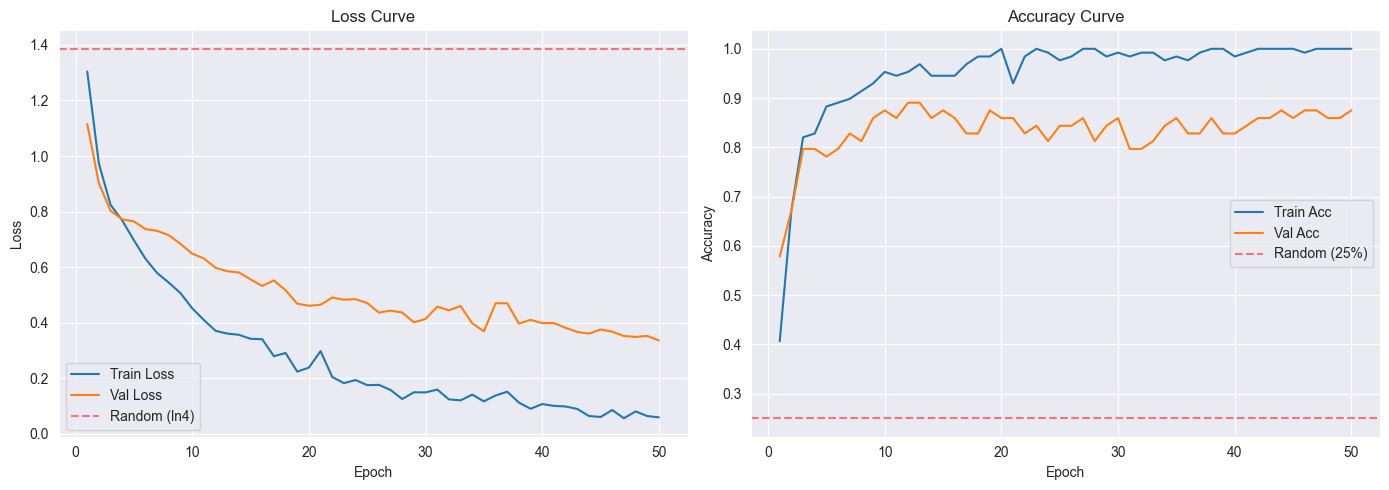

Best Val Acc: 0.8906 (Epoch 12)
Best Val Loss: 0.3365 (Epoch 50)

Classification Report (Best Model on Validation Set)
              precision    recall  f1-score   support

       Zone1     0.9231    0.7500    0.8276        16
       Zone2     1.0000    0.8125    0.8966        16
       Zone3     0.8824    0.9375    0.9091        16
       Zone4     0.7619    1.0000    0.8649        16

    accuracy                         0.8750        64
   macro avg     0.8918    0.8750    0.8745        64
weighted avg     0.8918    0.8750    0.8745        64



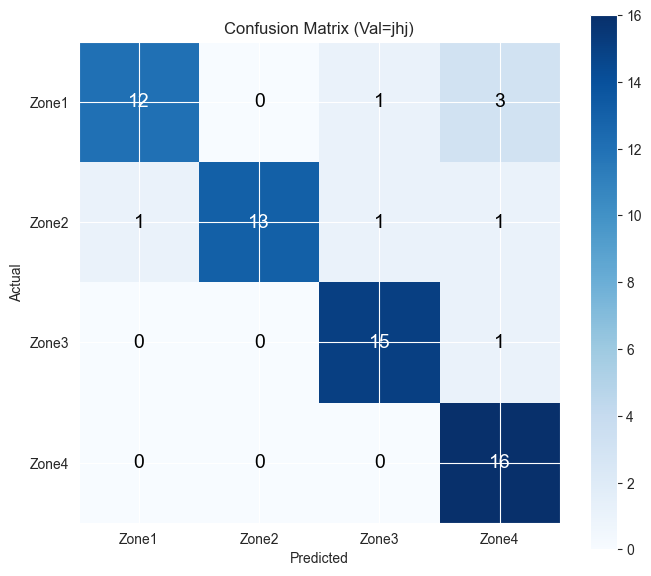


Overall Val Accuracy: 0.8750 (56/64)


In [9]:
import matplotlib.pyplot as plt

actual_epochs = len(train_losses)
epochs_range = range(1, actual_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, train_losses, label='Train Loss')
ax1.plot(epochs_range, val_losses, label='Val Loss')
ax1.axhline(y=1.386, color='r', linestyle='--', alpha=0.5, label='Random (ln4)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(epochs_range, train_accs, label='Train Acc')
ax2.plot(epochs_range, val_accs, label='Val Acc')
ax2.axhline(y=0.25, color='r', linestyle='--', alpha=0.5, label='Random (25%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Best Val Acc: {max(val_accs):.4f} (Epoch {val_accs.index(max(val_accs))+1})")
print(f"Best Val Loss: {best_val_loss:.4f} (Epoch {best_epoch})")

# --- Best 모델로 Val 추론 → Classification Report & Confusion Matrix ---
ZONE_NAMES = ['Zone1', 'Zone2', 'Zone3', 'Zone4']

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification Report
print("\n" + "=" * 55)
print("Classification Report (Best Model on Validation Set)")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=ZONE_NAMES, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=ZONE_NAMES, yticklabels=ZONE_NAMES,
       xlabel='Predicted', ylabel='Actual',
       title=f'Confusion Matrix (Val={VAL_SUBJECT})')

# 셀 안에 숫자 표시
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14)

plt.tight_layout()
plt.show()

# 전체 정확도
overall_acc = np.sum(all_preds == all_labels) / len(all_labels)
print(f"\nOverall Val Accuracy: {overall_acc:.4f} ({np.sum(all_preds == all_labels)}/{len(all_labels)})")